# 🏒 Player Tracking Analysis
### Analyzing Player Movement using Big Data Cup 2021 data

In [1]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.animation as animation
import seaborn as sns

print("Libraries loaded successfully!")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Libraries loaded successfully!


Let's first take a look at all of the data to better understand it!

In [2]:
df_w = pd.read_csv('hackathon_womens.csv')


print(df_w.shape)


df_w.head()


(24002, 21)


,game_date,Home Team,Away Team,Period,Clock,Home Team Skaters,Away Team Skaters,Home Team Goals,Away Team Goals,Team,...,Event,X Coordinate,Y Coordinate,Detail 1,Detail 2,Detail 3,Detail 4,Player 2,X Coordinate 2,Y Coordinate 2
0,2018-02-11,Olympic (Women) - Canada,Olympic (Women) - Olympic Athletes from Russia,1,20:00,5,5,0,0,Olympic (Women) - Canada,...,Faceoff Win,100,42,Backhand,NaN,NaN,NaN,Lyudmila Belyakova,NaN,NaN
1,2018-02-11,Olympic (Women) - Canada,Olympic (Women) - Olympic Athletes from Russia,1,19:59,5,5,0,0,Olympic (Women) - Canada,...,Puck Recovery,91,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-02-11,Olympic (Women) - Canada,Olympic (Women) - Olympic Athletes from Russia,1,19:59,5,5,0,0,Olympic (Women) - Canada,...,Dump In/Out,106,81,Retained,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-02-11,Olympic (Women) - Canada,Olympic (Women) - Olympic Athletes from Russia,1,19:59,5,5,0,0,Olympic (Women) - Canada,...,Zone Entry,106,81,Dumped,NaN,NaN,NaN,Liana Ganeyeva,NaN,NaN
4,2018-02-11,Olympic (Women) - Canada,Olympic (Women) - Olympic Athletes from Russia,1,19:53,5,5,0,0,Olympic (Women) - Canada,...,Puck Recovery,168,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_w.columns.tolist()

['game_date',
 'Home Team',
 'Away Team',
 'Period',
 'Clock',
 'Home Team Skaters',
 'Away Team Skaters',
 'Home Team Goals',
 'Away Team Goals',
 'Team',
 'Player',
 'Event',
 'X Coordinate',
 'Y Coordinate',
 'Detail 1',
 'Detail 2',
 'Detail 3',
 'Detail 4',
 'Player 2',
 'X Coordinate 2',
 'Y Coordinate 2']

In [4]:
df_w['Event'].value_counts()

Event
Play               7424
Puck Recovery      6960
Incomplete Play    2681
Zone Entry         1800
Dump In/Out        1682
Shot               1615
Takeaway            885
Faceoff Win         783
Penalty Taken       116
Goal                 56
Name: count, dtype: int64

In [5]:
df_w["Detail 1"].value_counts()

Detail 1
Direct                     6817
Indirect                   3288
Lost                       1488
Carried                    1049
Wristshot                   779
Backhand                    640
Dumped                      589
Snapshot                    509
Slapshot                    227
Retained                    194
Played                      162
Forehand                    143
Deflection                   81
Fan                          56
Roughing                     30
Tripping                     24
Wrap Around                  19
Interference                 13
Cross-checking               11
Slashing                     10
Hooking                      10
Holding                       7
Goalkeeper interference       3
High-sticking                 3
Too many men on the ice       2
Delay of game                 1
Closing hand on puck          1
Boarding                      1
Name: count, dtype: int64

We need to convert the clock "object" dtype to a more friendly data type (into seconds)

While making this function we will want to handle how we determine which period the event happend in

let's make our function first, then create a new "abs_seconds" col to apply the function to

In [6]:
def abs_time(p,clock):
    
    parts = clock.split(':')
    minutes = int(parts[0])
    seconds = int(parts[1])
    
    if p == 1:
        return 1200 - (minutes * 60 + seconds)
    
    elif p == 2:
        return 1200 + (1200 - (minutes * 60 + seconds))
        
    else: 
        return 2400 + ( 1200 - (minutes * 60 + seconds))
    

In [7]:
df_w['abs_seconds'] = df_w.apply(lambda row: abs_time(row['Period'], row['Clock']), axis = 1)

Verify that column was created and holds the correct infomation

In [8]:
df_w['abs_seconds'].tail()

23997    3591
23998    3593
23999    3594
24000    3596
24001    3599
Name: abs_seconds, dtype: int64

Perfect, now the time counts up to the end of the game. This will allow us to analyze goal events, because we needed a way to be able to create windows of about 30 seconds so we can analyze plays leading to a goal and differentre between goals made in the first, second and third period of the game.

In [9]:
df_w['game_date'].unique()

array(['2018-02-11', '2018-02-13', '2018-02-14', '2018-02-19',
       '2018-02-21', '2018-10-19', '2018-10-20', '2019-02-12',
       '2019-02-14', '2019-02-17', '2019-04-06', '2019-04-13',
       '2019-04-14'], dtype=object)

In [10]:
df_w['Home Team'].unique()

array(['Olympic (Women) - Canada', 'Olympic (Women) - United States',
       'Olympic (Women) - Olympic Athletes from Russia',
       'St. Lawrence Saints', 'Clarkson Golden Knights',
       'Olympic (Women) - Finland'], dtype=object)

The data spans 7 days in 2018 and 5 days in 2019. In this analysis we will be looking specifically at the game on February 14th 2018 (2018-02-14) This is an Olympic Game between Team USA vs Team CANADA (Womens)

In [30]:
df = df_w[df_w['game_date'] == '2018-02-14'].copy()

In [12]:
df.head(10)

,game_date,Home Team,Away Team,Period,Clock,Home Team Skaters,Away Team Skaters,Home Team Goals,Away Team Goals,Team,...,X Coordinate,Y Coordinate,Detail 1,Detail 2,Detail 3,Detail 4,Player 2,X Coordinate 2,Y Coordinate 2,abs_seconds
3499,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,20:00,5,5,0,0,Olympic (Women) - Canada,...,100,42,Backhand,NaN,NaN,NaN,Brianna Decker,NaN,NaN,0
3500,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:58,5,5,0,0,Olympic (Women) - Canada,...,80,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3501,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:58,5,5,0,0,Olympic (Women) - Canada,...,80,50,Direct,NaN,NaN,NaN,Lauriane Rougeau,63.0,20.0,2
3502,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:57,5,5,0,0,Olympic (Women) - Canada,...,66,15,Indirect,NaN,NaN,NaN,Sarah Nurse,100.0,3.0,3
3503,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:56,5,5,0,0,Olympic (Women) - Canada,...,100,3,Lost,NaN,NaN,NaN,NaN,NaN,NaN,4
3504,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:56,5,5,0,0,Olympic (Women) - Canada,...,100,3,Dumped,NaN,NaN,NaN,Cayla Barnes,NaN,NaN,4
3505,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:51,5,5,0,0,Olympic (Women) - United States,...,3,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
3506,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:48,5,5,0,0,Olympic (Women) - United States,...,11,78,Indirect,NaN,NaN,NaN,Cayla Barnes,12.0,77.0,12
3507,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:45,5,5,0,0,Olympic (Women) - Canada,...,173,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
3508,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,1,19:45,5,5,0,0,Olympic (Women) - Canada,...,173,3,Direct,NaN,NaN,NaN,Emily Clark,183.0,22.0,15


Now that we have handled all of the data cleaning, lets start digging into goal tracking and player tracking metrics

In [13]:
goals = df[df['Event'] == 'Goal']
goals.head(5)

,game_date,Home Team,Away Team,Period,Clock,Home Team Skaters,Away Team Skaters,Home Team Goals,Away Team Goals,Team,...,X Coordinate,Y Coordinate,Detail 1,Detail 2,Detail 3,Detail 4,Player 2,X Coordinate 2,Y Coordinate 2,abs_seconds
4355,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,2,12:44,4,5,0,0,Olympic (Women) - Canada,...,175,46,Snapshot,On Net,t,t,NaN,NaN,NaN,1636
4591,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,2,5:06,5,5,0,1,Olympic (Women) - Canada,...,165,14,Snapshot,On Net,t,f,NaN,NaN,NaN,2094
4777,2018-02-14,Olympic (Women) - United States,Olympic (Women) - Canada,3,19:38,5,5,0,2,Olympic (Women) - United States,...,170,34,Snapshot,On Net,f,f,NaN,NaN,NaN,2422


For each goal, we are going to create a 30 sec window, where we can then analyze those lead up plays to a goal. We also want these next few methods to be dynamic, so that we can apply them to other sets of goals in the dataset.


In [14]:
goal_windows = {}

for i, goal in goals.iterrows():

   
    goal_time = goal["abs_seconds"]
    window = df[
        (df['abs_seconds'] >= goal_time - 30) &
        (df['abs_seconds'] <= goal_time)
    ]
    goal_windows[i] = window

Since we did this in a dynamic way, we can handle different games in this data set at will

In [15]:
for goal_idx, window in goal_windows.items():
    print(f"Goal {goal_idx}: {len(window)} events")

Goal 4355: 12 events
Goal 4591: 18 events
Goal 4777: 18 events


Now that we have identified each goal and the sequence of plays within the 30 seconds leading up to it, we can create a short animation to visualize how each goal unfolded. This gives us an intuitive way to understand the flow of play before we dive deeper into the analysis.


In [16]:
def clean_time(time):
    
    minutes = time // 60
    seconds = time % 60
    
    return f"{minutes}:{seconds:02d}"

On the animation, I want to have a way to quickly understand when the goal happened. The clean_time function will give us a "pretty" way to see the time at the top

In [17]:
from matplotlib.patches import Arc, Circle, Rectangle

def draw_rink(ax):
    # Rink outline
    ax.set_facecolor('#f0f0f0')
    rink = Rectangle((0, 0), 200, 85, linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rink)
    
    
    # Goal crease
    crease = Arc((11, 42.5), width=12, height=7, angle=0, theta1=270, theta2=90, color='lightblue', linewidth=2)
    ax.add_patch(crease)
    
    crease2 = Arc((189, 42.5), width=12, height=7, angle=0, theta1=90, theta2=270, color='lightblue', linewidth=2)
    ax.add_patch(crease2)
    
    # Goal line
    ax.axvline(x=11, color='red', linewidth=2)
    ax.axvline(x=189, color='red', linewidth=2)
    
    # Blue line
    ax.axvline(x=75, color='blue', linewidth=2)
    ax.axvline(x=125, color='blue', linewidth=2)
    
    # Center line
    ax.axvline(x=100, color='red', linewidth=2)
    
    
    # Face-off circles
    circle1 = Circle((69, 21), 5, linewidth=2, edgecolor='red', facecolor='none')
    circle2 = Circle((69, 64), 5, linewidth=2, edgecolor='red', facecolor='none')
    circle3 = Circle((131, 21), 5, linewidth=2, edgecolor='red', facecolor='none')
    circle4 = Circle((131, 64), 5, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    ax.add_patch(circle3)
    ax.add_patch(circle4)
    
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 85)
    ax.axis('off')

For the visualization, we need a way to represent the rink. The draw_rink function will give us a nice, but simple representation.

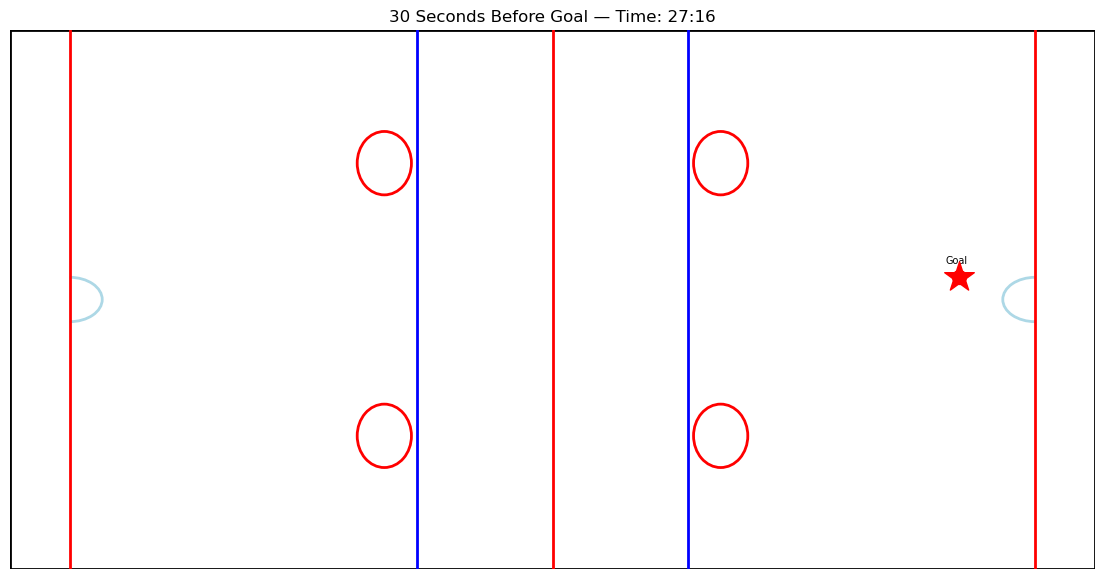

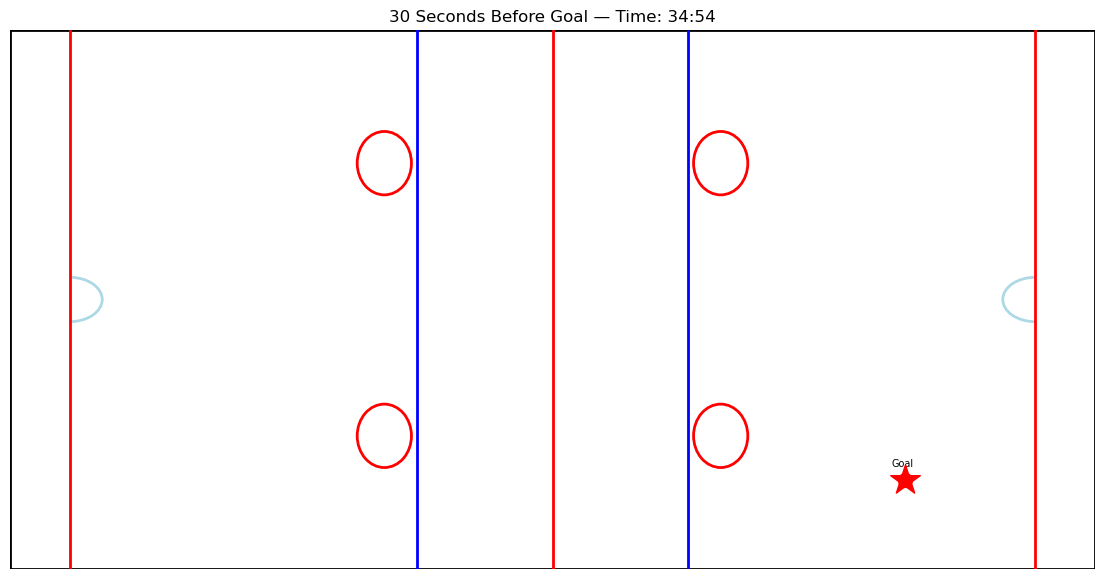

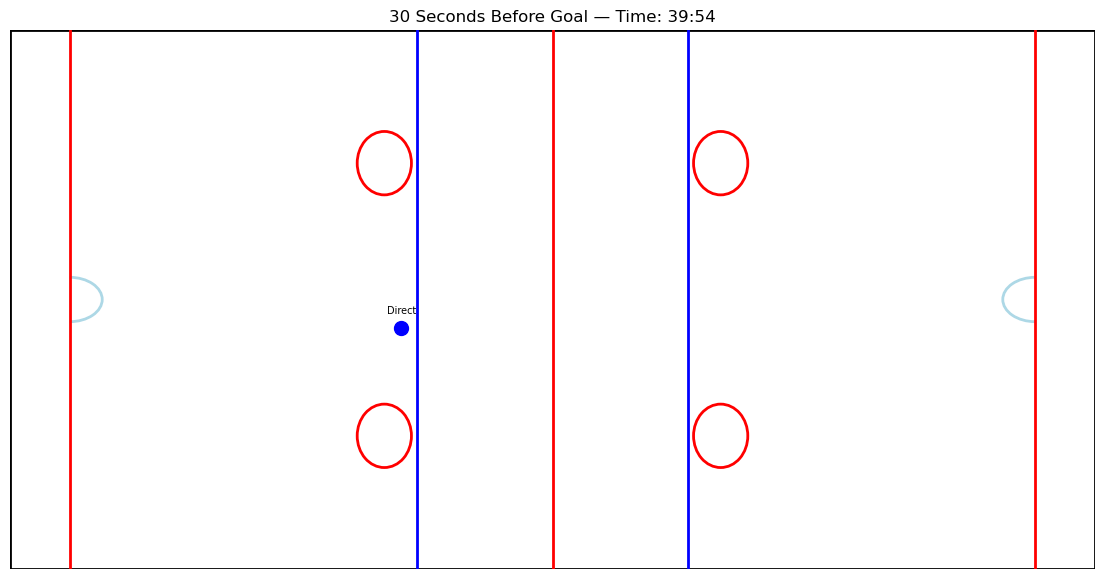

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


team_colors = {"Olympic (Women) - United States":'#0000FF', "Olympic (Women) - Canada":'#FF0000'}

def add_annotation(row, text):
    label = row[text].replace(' ', '\n')
    ax.annotate(label,
                        (row['X Coordinate'],
                        row['Y Coordinate']),
                    fontsize = 7,
                    xytext = (-10,10),
                    textcoords='offset points')
    
def update(frame):
    ax.clear()
    draw_rink(ax)
    
    # filter to events up to current frame
    current = window[window['abs_seconds'] == frame]

    
    # plot team events color 
    ax.scatter(current['X Coordinate'], current['Y Coordinate'], 
               c=current["Team"].map(team_colors), s=100)
    
    
    # plot goal separately as a star if it's in current frame
    goal = current[current['Event'] == "Goal"]
    if len(goal) > 0:
        # match goal and team color
        ax.scatter(goal['X Coordinate'], goal['Y Coordinate'],
                  marker="*", s=500, c=goal["Team"].map(team_colors), zorder=5)
    
    frame = clean_time(frame)
    ax.set_title(f'30 Seconds Before Goal — Time: {frame}')
    
    
    for _, row in current.iterrows():
        
        if pd.notna(row["Detail 1"]) and row["Event"] != "Goal":
            add_annotation(row, "Detail 1")
            
        
        
        # Not a goal and has an event tag
        elif pd.notna(row["Event"]) and row["Event"] != "Goal":
            add_annotation(row, "Event")
        
        # Goal
        else:
            add_annotation(row, "Event")




    
for goal_idx, window in goal_windows.items():

    time_steps = sorted(window['abs_seconds'].unique())

   

    fig, ax = plt.subplots(figsize=(14, 7))
    

    ani = FuncAnimation(fig, update, frames=time_steps, interval=500)

    ani.save(f'{goal_idx}_goal.gif', writer='pillow', fps=1)
    


For a clearer visualization of the goal animations, please refer to the GIF files located in the project folder.

In [37]:
from math import dist

left_net = (11, 42.5)
right_net = (189, 42.5)

df['dist_to_left'] = df.apply(lambda row: dist((row['X Coordinate'], row['Y Coordinate']), left_net), axis=1)
df['dist_to_right'] = df.apply(lambda row: dist((row['X Coordinate'], row['Y Coordinate']), right_net), axis=1)

# determine which net each event was closest to
df['closest_net'] = df.apply(lambda row: 'left' if row['dist_to_left'] < row['dist_to_right'] else 'right', axis=1)
df['dist_to_closest_net'] = df[['dist_to_left', 'dist_to_right']].min(axis=1)

df.groupby('closest_net')['dist_to_closest_net'].describe()


,count,mean,std,min,25%,50%,75%,max
closest_net,,,,,,,,
left,918.0,40.881071,24.661702,2.500000,19.704012,37.479823,58.388783,95.059192
right,931.0,49.800381,24.118439,2.692582,29.744224,50.618672,70.030345,97.371710
